# Exploring the tumor

This notebook digs into the **biology** stage: spatial structure, the CINner-style selection
model, clonal dynamics, and how treatment acts on cells. We rebuild the same small tumor the
other notebooks use (`example_config.yaml`, seed 2), keeping the live `Tumor` object so we can
colour the spatial grid by any per-cell quantity.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import iscc
from iscc.tumor.models import GenotypeTumor
from iscc.constants import normal_names

CONFIG = os.path.join(os.getcwd(), "example_config.yaml")
# The same cm-scale DCIS -> IDC tissue as the other notebooks (~8.5 mm, ~10^6 cells). Growing to the
# DCIS->IDC state takes ~3 min (tau-leaping + passenger coarsening).
tumor = GenotypeTumor(config=CONFIG, seed=2)
tumor.grow(n_steps=150, seed=2)
print("cancer:", tumor.get_cancer_size(), "| total:", tumor.get_tumor_size(),
      "| genome:", tumor.n_genes, "genes")

cancer: 254747 | total: 520343 | genome: 600 genes


## Spatial structure

`plot_tissue` draws the **deme grid straight from the per-deme counts**, so the spatial overview stays
complete at cm-scale (`plot_grid`, which reads the memory-safe `cell_data` subsample, would go holey).
Three complementary views:

- `"state"` — categorical histology: stroma / duct(normal) / **DCIS** (cancer inside a duct) / **IDC**
  (cancer invaded into the stroma);
- `"cancer_frac"` — the per-deme cancer fraction (density);
- `"clone"` — each cancer deme coloured by its dominant **driver clone** (the distinct set of driver
  oncogene/TSG mutations). This is the same colouring used by the Muller and the phylogeny below, so
  one clonal story reads across space (this grid), time (Muller), and ancestry (tree).

You can see the single founder's DCIS ducts and the focal invasive masses that broke out of them.

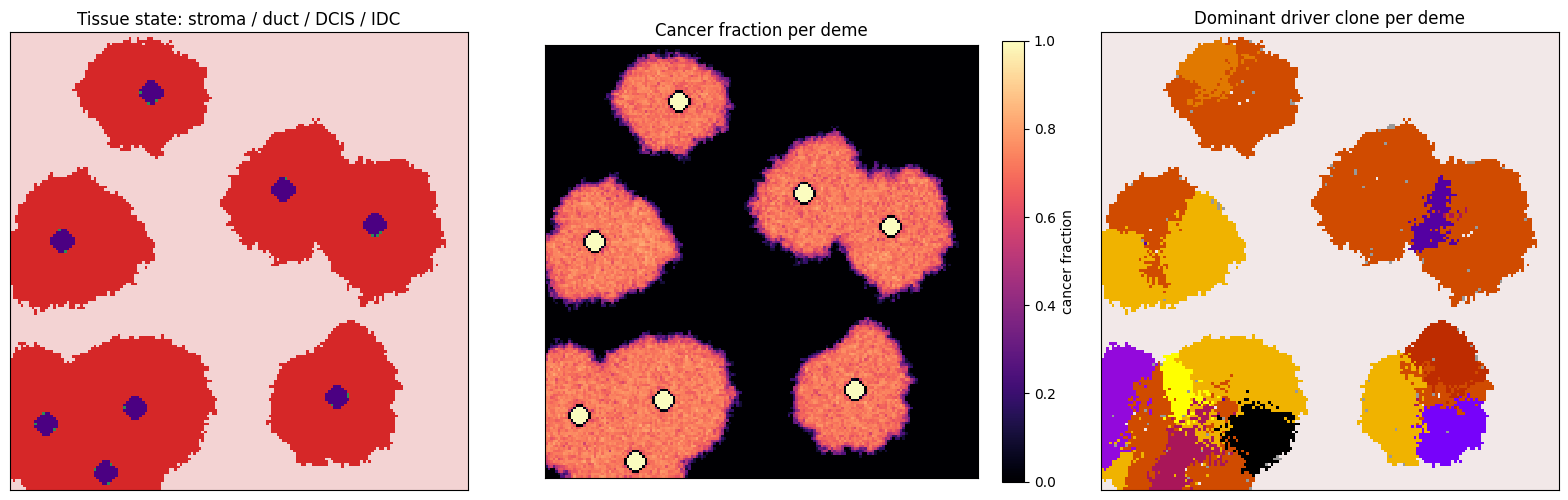

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
tumor.plot_tissue(ax=axes[0], color="state")
axes[0].set_title("Tissue state: stroma / duct / DCIS / IDC")
tumor.plot_tissue(ax=axes[1], color="cancer_frac")
axes[1].set_title("Cancer fraction per deme")
tumor.plot_tissue(ax=axes[2], color="clone")
axes[2].set_title("Dominant driver clone per deme")
plt.tight_layout()

## Clonal dynamics

The Muller plot shows how cancer clones rise and fall over the simulation. `by_drivers=True` colours
by **driver clone** — the distinct combination of driver oncogene/TSG mutations a clone carries —
collapsing passenger-only diversity so the sweeps are legible; `min_freq` merges tiny clones. This is
the same colouring as the clone grid above and the phylogeny below — one founder, three views.

Text(0.5, 1.0, 'Clonal dynamics (by driver clone) — a single founder + its subclones')

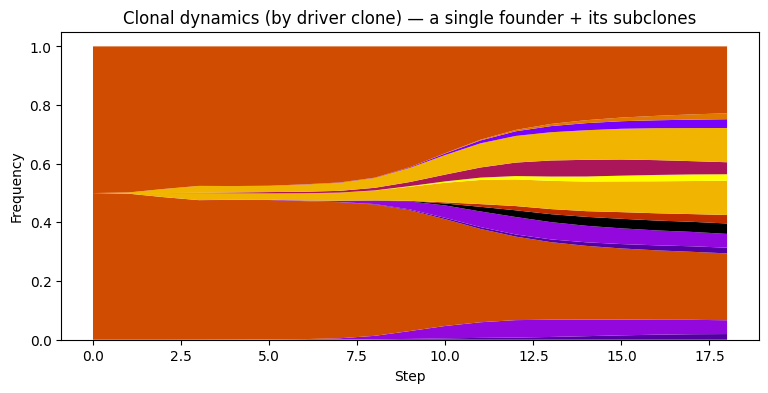

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
tumor.plot_muller(ax=ax, by_drivers=True, min_freq=0.02)
ax.set_title("Clonal dynamics (by driver clone) — a single founder + its subclones")

## Cell phylogeny

The Muller shows clone *frequencies* over time; the phylogeny shows the *ancestry* directly. We
subsample cancer cells (weighted by clone size), build their induced lineage tree from
`genotypes_parents`, and draw it radially — branches and leaves in the same driver-clone colours as
the Muller and grid, so the trunk is the founder and the coloured clades are its driver subclones.

Text(0.5, 1.0, 'Cell phylogeny (by driver clone)')

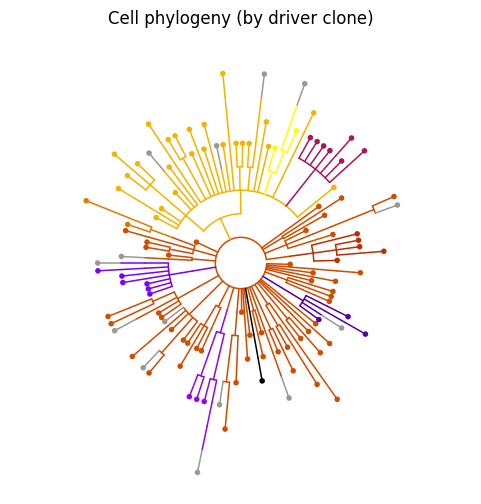

In [4]:
# Radial cell phylogeny, drawn straight to the axes (no image file). Leaves are subsampled cancer
# cells; branches and leaves take the SAME driver-clone colours as the Muller and the grid.
fig, ax = plt.subplots(figsize=(6, 6))
tumor.plot_phylogeny(ax=ax, sample_size=150, seed=0)
ax.set_title("Cell phylogeny (by driver clone)")

## The CINner-style selection model

Fitness is copy-number aware: oncogene copies/mutations raise the division rate,
tumour-suppressor copies/mutations lower it. We can see this in the per-cell ground truth —
cells carrying more mutated oncogenes tend to divide faster.

Text(0.5, 1.0, 'Selection: driver load vs fitness')

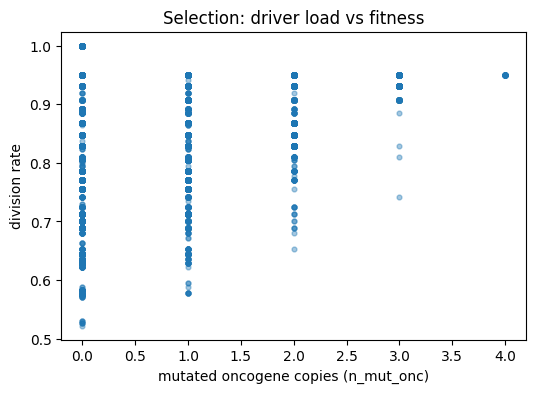

In [5]:
evo = tumor.cell_data["cell_evo"].copy()
evo = evo[evo["division_rate"] > 0]  # cancer cells (normal cells have division_rate 0)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(evo["n_mut_onc"], evo["division_rate"], alpha=0.4, s=12)
ax.set_xlabel("mutated oncogene copies (n_mut_onc)")
ax.set_ylabel("division rate")
ax.set_title("Selection: driver load vs fitness")

## How treatment acts on cells

A treatment has a **dosing schedule** and a **per-cell effect**. An (untargeted) chemotherapy
raises a cancer cell's death rate by a factor `rate_multiplier ** (1 - treatment_resistance)`,
so more resistant cells are affected less. Below we visualise both: the dose over time, and the
effective death-rate multiplier as a function of a cell's resistance.

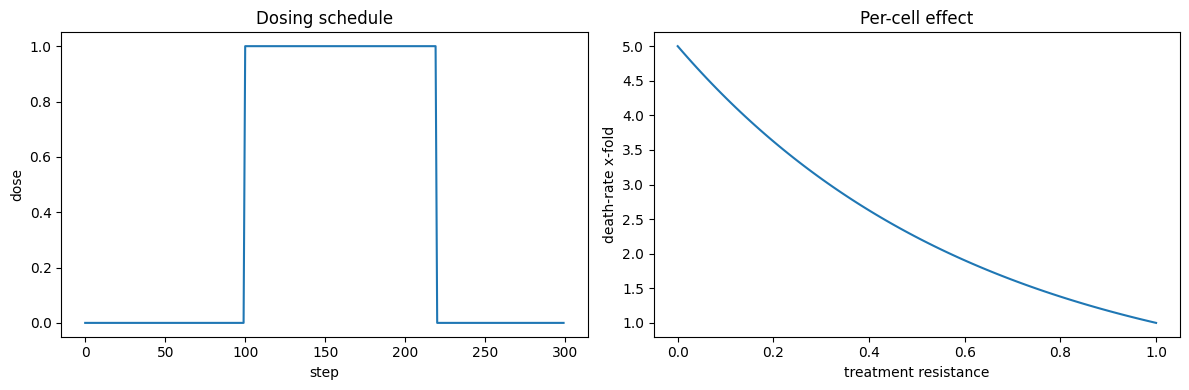

In [6]:
chemo = iscc.treatment.Chemotherapy(adaptive=False, start=100, duration=120,
                                    effectiveness=1.0, toxicity=0.1, rate_multiplier=5.0)
steps = np.arange(0, 300)
dose = [chemo.get_dosage(s, tumor_size=1000) for s in steps]

resistance = np.linspace(0, 1, 100)
mult = chemo.rate_multiplier ** (1 - resistance)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(steps, dose); axes[0].set_xlabel("step"); axes[0].set_ylabel("dose")
axes[0].set_title("Dosing schedule")
axes[1].plot(resistance, mult); axes[1].set_xlabel("treatment resistance")
axes[1].set_ylabel("death-rate x-fold"); axes[1].set_title("Per-cell effect")
plt.tight_layout()

> The population-level *magnitude* of response is currently muted by the default
> treatment-resistance parameterization (cells start highly resistant); making longitudinal
> pre/post-treatment response realistic is part of the treatment-realism milestone. The
> scheduling and per-cell mechanics shown here are what that work will build on.

**Next:** [Exploring the data](03_data_overview.ipynb) takes a sample of a tumor like this one and walks through
every molecular assay (bulk/single-cell DNA, scRNA, Visium).